# Cinética de Procesos (Sesión 04)

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import src.ratelaws as rate

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 1 Definiciones

## 1.1 Reacciones paralelas

**En las reacciones paralelas, también llamadas reacciones competitivas, el reactivo se consume por reacciones que compiten entre si, formando distintos productos.**

Considere la descomposición de la especie $\mathrm{A}$ por cualquiera de de dos caminos posibles:

$$\mathrm{A} \xrightarrow[]{k_{1}} {B} \quad \text{producto deseado}$$

$$\mathrm{A} \xrightarrow[]{k_{2}} {C} \quad \text{producto no deseado}$$

Con sus tasas de reacción correspondientes:

$$r_{\mathrm{A}} = \frac{dC_{A}}{dt} = -k_{1} C_{\mathrm{A}}^{a_1} - k_{2} C_{\mathrm{A}}^{a_2}$$

$$r_{\mathrm{B}} = \frac{dC_{B}}{dt} = k_{1} C_{\mathrm{A}}^{a_1}$$

$$r_{\mathrm{C}} = \frac{dC_{C}}{dt} = k_{2} C_{\mathrm{A}}^{a_2}$$

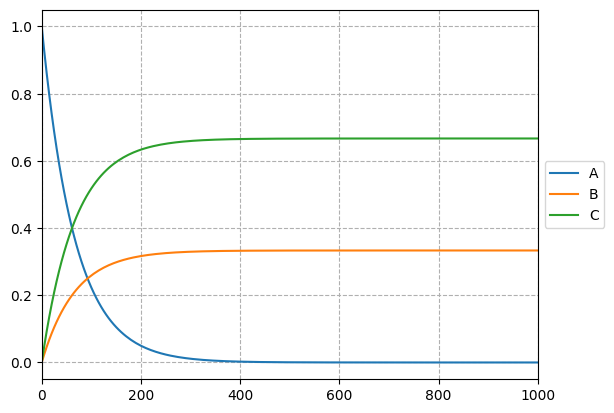

In [52]:
# Global problem definition
species = ["A", "B", "C"]
C0 = (1.0, 0.0, 0.0) # concentration
k1, k2 = 5e-3, 1e-2 # kinetic constants
n1, n2 = 1.0, 1.0 # orders

def batch(t, C):
    dC_dt = np.array([
        -k1*C[0]**(n1) - k2*C[0]**(n2), #rA
        k1*C[0]**(n1), #rB
        k2*C[0]**(n2) #rC
    ])
    return dC_dt
def batchEnd(t, C):
    return C[0]
batchEnd.terminal = True

t_span = (0, 1000)
dt = 5
t_eval = np.arange(t_span[0], t_span[1]+dt, dt)
sol = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    #events=batchEnd, 
    t_eval=t_eval
)

fig, ax = plt.subplots()
for specie, y in zip(species, sol.y):
    ax.plot(sol.t, y, label=specie)
ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax.set_xlim(0, 1000)
ax.grid(ls='--')
plt.show()

## 1.2 Reacciones en serie

**En las reacciones en serie, también llamadas reacciones consecutivas, el reactivo forma un producto intermedio, que posteriormente se tranforma en otro producto.**

Considere la reacción:

$$\mathrm{A} \xrightarrow[]{k_{1}} \mathrm{B} \xrightarrow[]{k_{2}} \mathrm{C}$$

Con sus tasas de reacción correspondientes:

$$r_{\mathrm{A}} = \frac{dC_{\mathrm{A}}}{dt} = -k_{1} C_{\mathrm{A}}^{a_1}$$

$$r_{\mathrm{B}} = \frac{dC_{\mathrm{B}}}{dt} = k_{1} C_{\mathrm{A}}^{a_1} - k_{2} C_{\mathrm{B}}^{b_1}$$

$$r_{\mathrm{C}} = \frac{dC_{\mathrm{C}}}{dt} = k_{2} C_{\mathrm{B}}^{b_1}$$

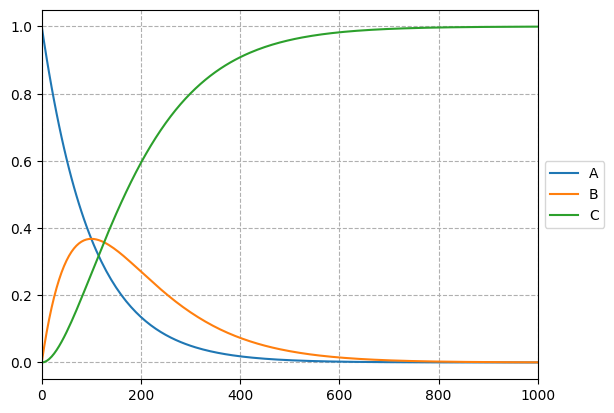

In [57]:
# Global problem definition
species = ["A", "B", "C"]
C0 = (1.0, 0.0, 0.0) # concentration
k1, k2 = 1e-2, 1e-2 # kinetic constants
n1, n2 = 1.0, 1.0 # orders

def batch(t, C):
    dC_dt = ([
        -k1*C[0]**(n1), #rA
        k1*C[0]**(n1) - k2*C[1]**(n2), #rB
        k2*C[1]**(n2) #rC
    ])
    return dC_dt
def batchEnd(t, C):
    return C[0]
batchEnd.terminal = True

t_span = (0, 1000)
dt = 5
t_eval = np.arange(t_span[0], t_span[1]+dt, dt)
sol = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    #events=batchEnd, 
    t_eval=t_eval
)

fig, ax = plt.subplots()
for specie, y in zip(species, sol.y):
    ax.plot(sol.t, y, label=specie)
ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax.set_xlim(0, 1000)
ax.grid(ls='--')
plt.show()

## 1.3 Reacciones independientes

**Las reacciones independientes ocurren simultaneamente, sin que existan interacciones entre los productos o los reactivos.**

Considere las reacciones:

$$\mathrm{A} \xrightarrow[]{k_{1}} \mathrm{B} + \mathrm{C}$$

$$\mathrm{D} \xrightarrow[]{k_{2}} \mathrm{E} + \mathrm{F}$$

Con sus tasas de reacción correspondientes:

$$r_{\mathrm{A}} = \frac{dC_{\mathrm{A}}}{dt} = -k_{1} C_{\mathrm{A}}^{a_1}$$
$$r_{\mathrm{B}} = \frac{dC_{\mathrm{B}}}{dt} = k_{1} C_{\mathrm{A}}^{a_1}$$
$$r_{\mathrm{C}} = \frac{dC_{\mathrm{C}}}{dt} = k_{1} C_{\mathrm{A}}^{a_1}$$

$$r_{\mathrm{D}} = \frac{dC_{\mathrm{D}}}{dt} = -k_{2} C_{\mathrm{D}}^{d_1}$$
$$r_{\mathrm{E}} = \frac{dC_{\mathrm{E}}}{dt} = k_{2} C_{\mathrm{D}}^{d_1}$$
$$r_{\mathrm{F}} = \frac{dC_{\mathrm{F}}}{dt} = k_{2} C_{\mathrm{D}}^{d_1}$$

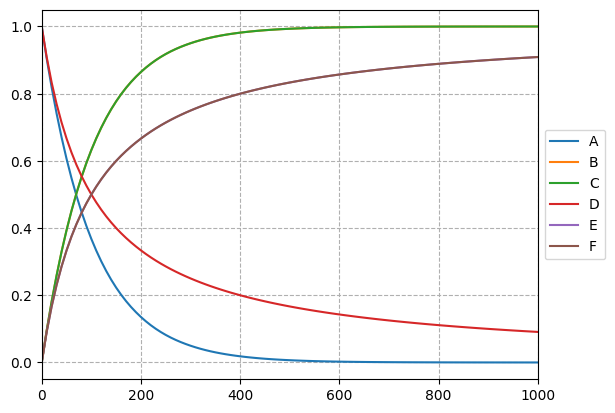

In [55]:
# Global problem definition
species = ["A", "B", "C", "D", "E", "F"]
C0 = (1.0, 0.0, 0.0, 1.0, 0.0, 0.0) # concentration
k1, k2 = 1e-2, 1e-2 # kinetic constants
n1, n2 = 1.0, 2.0 # orders

def batch(t, C):
    dC_dt = ([
        -k1*C[0]**(n1), #rA
        k1*C[0]**(n1),  #rB
        k1*C[0]**(n1),  #rC
        -k2*C[3]**(n2), #rD
        k2*C[3]**(n2),  #rE
        k2*C[3]**(n2)   #rF
    ])
    return dC_dt
def batchEnd(t, C):
    return C[0], C[3]
batchEnd.terminal = True

t_span = (0, 1000)
dt = 10
t_eval = np.arange(t_span[0], t_span[1]+dt, dt)
sol = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    #events=batchEnd, 
    t_eval=t_eval
)

fig, ax = plt.subplots()
for specie, y in zip(species, sol.y):
    ax.plot(sol.t, y, label=specie)
ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax.set_xlim(0, 1000)
ax.grid(ls='--')
plt.show()

## 1.4 Reacciones complejas

**Las reacciones complejas, tienen mecanismos en los que se pueden tener combinaciones de reacciones paralelas, en serie y/o independientes.**

Considere las reacciones:

$$\mathrm{A + B} \xrightarrow[]{k_{1}} \mathrm{C + D}$$

$$\mathrm{A + C} \xrightarrow[]{k_{2}} \mathrm{E}$$

$$\mathrm{E} \xrightarrow[]{k_{3}} \mathrm{F}$$

Con sus tasas de reacción correspondientes:

$$r_{\mathrm{A}} = \frac{dC_{\mathrm{A}}}{dt} = -k_{1} C_{\mathrm{A}}^{a_1} C_{\mathrm{B}}^{b_1} - k_{2} C_{\mathrm{A}}^{a_2} C_{\mathrm{C}}^{c_2}$$

$$r_{\mathrm{B}} = \frac{dC_{\mathrm{B}}}{dt} = -k_{1} C_{\mathrm{A}}^{a_1} C_{\mathrm{B}}^{b_1}$$

$$r_{\mathrm{C}} = \frac{dC_{\mathrm{C}}}{dt} = k_{1} C_{\mathrm{A}}^{a_1} C_{\mathrm{B}}^{b_1} - k_{2} C_{\mathrm{A}}^{a_2} C_{\mathrm{C}}^{c_2} $$

$$r_{\mathrm{D}} = \frac{dC_{\mathrm{D}}}{dt} = k_{1} C_{\mathrm{A}}^{a_1} C_{\mathrm{B}}^{b_1}$$

$$r_{\mathrm{E}} = \frac{dC_{\mathrm{E}}}{dt} = k_{2} C_{\mathrm{A}}^{a_2} C_{\mathrm{C}}^{c_2} - k_{3} C_{\mathrm{E}}^{e_{3}}$$

$$r_{\mathrm{F}} = \frac{dC_{\mathrm{F}}}{dt} =  k_{3} C_{\mathrm{E}}^{e_{3}}$$


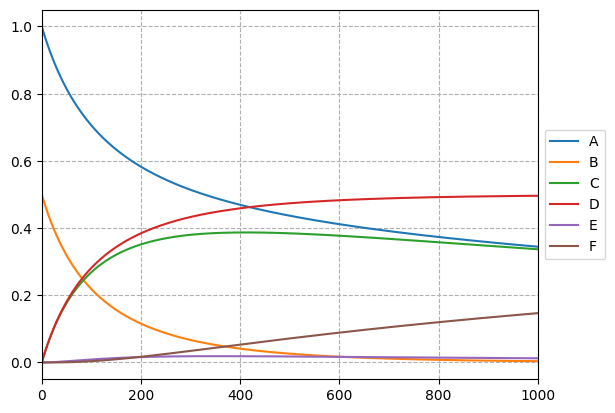

In [56]:
# Global problem definition
species = ["A", "B", "C", "D", "E", "F"]
C0 = (1.0, 0.5, 0.0, 0.0, 0.0, 0.0) # concentration
k1, k2, k3 = 1e-2, 1e-3, 1e-2 # kinetic constants
n1, n2, n3 = (1.0, 1.0), (1.0, 1.0), (1.0) # orders

def batch(t, C):
    dC_dt = ([
        -k1*C[0]**(n1[0])*C[1]**(n1[1]) - k2*C[0]**(n2[0])*C[2]**(n2[1]),   #rA
        -k1*C[0]**(n1[0])*C[1]**(n1[1]),                                    #rB
        k1*C[0]**(n1[0])*C[1]**(n1[1]) - k2*C[0]**(n2[0])*C[2]**(n2[1]),    #rC
        k1*C[0]**(n1[0])*C[1]**(n1[1]),                                     #rD
        k2*C[0]**(n2[0])*C[2]**(n2[1]) - k3*C[4]**(n3),                     #rE
        k3*C[4]**(n3)                                                       #rF
    ])
    return dC_dt
def batchEnd(t, C):
    return np.array([C[0], C[1]]).any() == 0.0
batchEnd.terminal = True

t_span = (0, 1000)
dt = 1
t_eval = np.arange(t_span[0], t_span[1]+dt, dt)
sol = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    #events=batchEnd, 
    t_eval=t_eval
)

fig, ax = plt.subplots()
for specie, y in zip(species, sol.y):
    ax.plot(sol.t, y, label=specie)
ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax.set_xlim(0, 1000)
ax.grid(ls='--')
plt.show()

## 1.5 Selectividad

### 1.5.1 Selectividad instantanea

La **selectividad Instantanea** se define como el cociente de las tasas de formación del producto deseado y de los productos no desados:

$$S_{_{\mathrm{D/U}}} = \frac{r_{\mathrm{D}}}{r_{\mathrm{N}}}

### 1.5.2 Selectividad global

La **selectividad global** se define como el cociente de número de moles deseados entre no deseados al parar la reacción en un reactor batch, o de flujos molares deseados entre no deseados a la salida de un reactor de flujo:

$$\tilde{S}_{_{D/U}} = \frac{N_{D}}{N_{N}} = \frac{F_{D}}{F_{N}} = \frac{C_{D}}{C_{N}}$$

## 1.6 Rendimiento fraccional

### 1.6.1 Rendimiento instantaneo

El **rendimiento instantaneo** se define como el cociente entre la tasa instantanea de formación de un producto y la tasa de consumo de un reactivo.

$$Y = \frac{r_{\mathrm{D}}}{-r_{\mathrm{A}}}$$

### 1.6.2 Rendimiento global

El **rendimineto global** se define como el cociente de número de moles de un producto que se han formados entre los moles de un reactivo que se han consumido al inactivar la reacción en un reactor Batch, o a la salida de un reactor de flujo:

$$\tilde{Y} = \frac{N_{\mathrm{R}}}{N_{\mathrm{A}}^0 - N_{\mathrm{A}}} = \frac{F_{\mathrm{R}}}{F_{\mathrm{A}}^0 - F_{\mathrm{A}}} = \frac{C_{\mathrm{R}}}{C_{\mathrm{A}}^0 - C_{\mathrm{A}}}$$